In [43]:
!pip install opencv-python
!pip install tensorflow

In [44]:
import cv2
from keras.applications.vgg16 import preprocess_input
from keras.models import Model
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from keras.applications.vgg16 import VGG16

from keras.preprocessing import image
from keras.applications.vgg16 import VGG16, preprocess_input, decode_predictions
import matplotlib.pyplot as plt


D:\Aninst\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 636s 1us/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 969ms/step


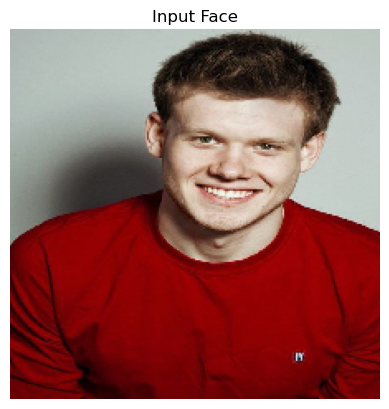

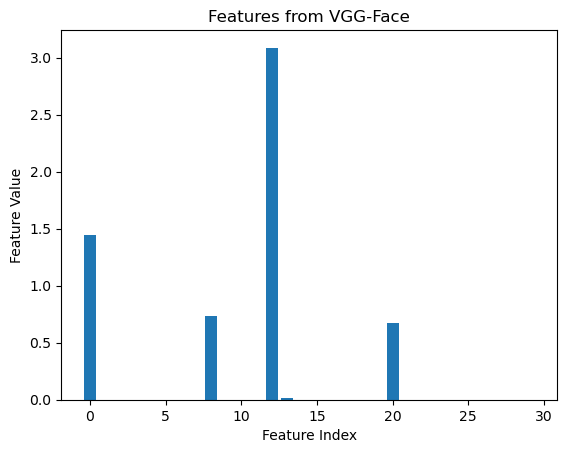

In [1]:
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Загрузка модели VGG-Face
base_model = VGG16(weights='imagenet')
model = Model(inputs=base_model.input, outputs=base_model.get_layer('fc2').output)

# Загрузка и предварительная обработка изображения лица
img_path = 'C:/Users/User/Desktop/img1.jpg'
img = load_img(img_path, target_size=(224, 224))
x = img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

# Получение вектора признаков для лица
features = model.predict(x)

# Отображение изображения
plt.imshow(img)
plt.axis('off')
plt.title('Input Face')
plt.show()

# Отображение первых 30 признаков для наглядности (вы можете отобразить больше или меньше признаков)
plt.bar(range(30), features[0][:30])
plt.title('Features from VGG-Face')
plt.xlabel('Feature Index')
plt.ylabel('Feature Value')
plt.show()


In [3]:
import cv2

# Загрузите предварительно обученный каскадный классификатор лиц
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

# Чтение изображения
img = cv2.imread('C:/Users/User/Desktop/img2.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Детекция лица
faces = face_cascade.detectMultiScale(gray, 1.1, 4)
for (x, y, w, h) in faces:
    face_roi = img[y:y+h, x:x+w]  # извлекаем ROI лица для дальнейшего анализа


In [4]:
face_roi

array([[[208, 196, 190],
        [208, 196, 190],
        [208, 196, 190],
        ...,
        [207, 197, 190],
        [207, 197, 190],
        [207, 197, 190]],

       [[208, 196, 190],
        [208, 196, 190],
        [208, 196, 190],
        ...,
        [207, 197, 190],
        [207, 197, 190],
        [207, 197, 190]],

       [[208, 196, 190],
        [208, 196, 190],
        [208, 196, 190],
        ...,
        [207, 197, 190],
        [207, 197, 190],
        [207, 197, 190]],

       ...,

       [[158, 173, 205],
        [155, 172, 205],
        [155, 172, 205],
        ...,
        [ 17,  12,  14],
        [ 19,  13,  14],
        [ 19,  13,  14]],

       [[159, 175, 204],
        [157, 172, 204],
        [157, 172, 204],
        ...,
        [ 18,  13,  15],
        [ 19,  13,  14],
        [ 20,  14,  15]],

       [[161, 177, 206],
        [156, 171, 203],
        [154, 169, 201],
        ...,
        [ 18,  13,  15],
        [ 19,  13,  14],
        [ 19,  13,  14]]

In [5]:
face_img = cv2.resize(face_roi, (224, 224))
x = img_to_array(face_img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

# Извлечение дескрипторов лица
toretto_features = model.predict(x)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 527ms/step


In [6]:
np.save('img2.npy', toretto_features)


In [8]:
# Загрузка сохраненных дескрипторов(преобразование img в вектор, описывает уникальные характеристики)
saved_features = np.load('img2.npy')

In [10]:
import cv2
import numpy as np
from keras.applications.vgg16 import VGG16, preprocess_input
from keras.models import Model
from tensorflow.keras.preprocessing.image import img_to_array


# 1. Инициализация модели VGG-Face и извлечение слоя fc2
base_model = VGG16(weights='imagenet')
model = Model(inputs=base_model.input, outputs=base_model.get_layer('fc2').output)

# 2. Функция для детекции и извлечения признаков лица
def get_face_features(img_path):
    # Детекция лица с использованием OpenCV
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 4)
    for (x, y, w, h) in faces:
        face_roi = img[y:y+h, x:x+w]

    face_img = cv2.resize(face_roi, (224, 224))
    x = img_to_array(face_img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    features = model.predict(x)
    return features

# 3. Сравнение признаков лица
def is_match(saved_features, new_features, threshold=10):
    distance = np.linalg.norm(saved_features - new_features)
    return distance < threshold

# 4. Демонстрация функциональности
saved_features = np.load('img2.npy')
new_image_path = "C:/Users/User/Desktop/img2.jpg"  # Замените на путь к новому изображению
new_features = get_face_features(new_image_path)

if is_match(saved_features, new_features):
    print("This is Nagiev!")
else:
    print("This is not Nagiev.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 660ms/step
This is Nagiev!


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 532ms/step


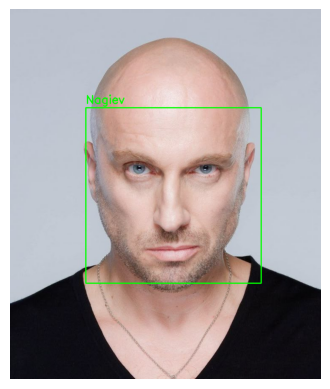

In [11]:
def display_image_with_results(img_path, features):
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
    faces = face_cascade.detectMultiScale(gray, 1.1, 4)

    for (x, y, w, h) in faces:
        if is_match(saved_features, features):
            cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
            cv2.putText(img, "Nagiev", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
        else:
            cv2.rectangle(img, (x, y), (x+w, y+h), (0, 0, 255), 2)
            cv2.putText(img, "Not Nagiev", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2)

    # Если вы работаете в Jupyter Notebook:
    from matplotlib import pyplot as plt
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Конвертация из BGR в RGB для корректного отображения в matplotlib
    plt.imshow(img)
    plt.axis('off')
    plt.show()

# Теперь вызываем функцию:
new_image_path = "C:/Users/User/Desktop/img2.jpg"
new_features = get_face_features(new_image_path)
display_image_with_results(new_image_path, new_features)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 544ms/step


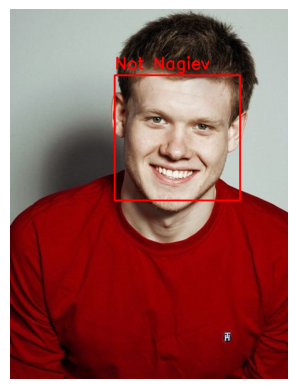

In [12]:
# Теперь вызываем функцию:
new_image_path = "C:/Users/User/Desktop/img1.jpg"
new_features = get_face_features(new_image_path)
display_image_with_results(new_image_path, new_features)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step


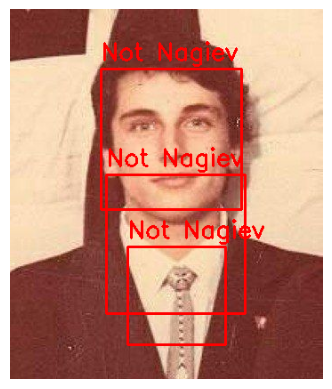

In [13]:
# Теперь вызываем функцию:
new_image_path = "C:/Users/User/Desktop/young_nagiev.jpg"
new_features = get_face_features(new_image_path)
display_image_with_results(new_image_path, new_features)

In [19]:
!pip install torch torchvision pillow numpy facenet-pytorch

     ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
      --------------------------------------- 0.3/15.8 MB ? eta -:--:--
     - -------------------------------------- 0.5/15.8 MB 2.1 MB/s eta 0:00:08
     - -------------------------------------- 0.5/15.8 MB 2.1 MB/s eta 0:00:08
     -- ------------------------------------- 1.0/15.8 MB 1.2 MB/s eta 0:00:13
     --- ------------------------------------ 1.3/15.8 MB 1.4 MB/s eta 0:00:11
     --- ------------------------------------ 1.3/15.8 MB 1.4 MB/s eta 0:00:11
     ---- ----------------------------------- 1.8/15.8 MB 1.2 MB/s eta 0:00:12
     ----- ---------------------------------- 2.1/15.8 MB 1.3 MB/s eta 0:00:11
     ------ --------------------------------- 2.6/15.8 MB 1.5 MB/s eta 0:00:10
     ------- -------------------------------- 3.1/15.8 MB 1.6 MB/s eta 0:00:09
     --------- ------------------------------ 3.7/15.8 MB 1.7 MB/s eta 0:00:08
     --------- ------------------------------ 3.9/15.8 MB 1.6 MB/s

  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [21 lines of output]
      Traceback (most recent call last):
        File "D:\Aninst\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 389, in <module>
          main()
          ~~~~^^
        File "D:\Aninst\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
                                   ~~~~^^^^^^^^^^^^^^^^^^^^^^^^
        File "D:\Aninst\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 143, in get_requires_for_build_wheel
          return hook(config_settings)
        File "C:\Users\User\AppData\Local\Temp\pip-build-env-yycyyh_t\overlay\Lib\site-packages\setuptools\build_meta.py", line 333, in get_requires_for_build_wheel
          return self._get_build_requires(config_settings, requ

In [24]:
!pip install transformers torch pillow requests

  Using cached transformers-5.3.0-py3-none-any.whl.metadata (32 kB)
  Using cached huggingface_hub-1.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached hf_xet-1.3.2-cp37-abi3-win_amd64.whl.metadata (4.9 kB)
   ---------------------------------------- 0.0/10.7 MB ? eta -:--:--
    --------------------------------------- 0.3/10.7 MB ? eta -:--:--
   - -------------------------------------- 0.5/10.7 MB 1.3 MB/s eta 0:00:08
   --- ------------------------------------ 1.0/10.7 MB 1.9 MB/s eta 0:00:06
   --- ------------------------------------ 1.0/10.7 MB 1.9 MB/s eta 0:00:06
   ----- ---------------------------------- 1.6/10.7 MB 1.6 MB/s eta 0:00:06
   ------ --------------------------------- 1.8/10.7 MB 1.5 MB/s eta 0:00:06
   ------- -------------------------------- 2.1/10.7 MB 1.6 MB/s eta 0:00:06
   -------- ---------------------------

In [77]:
from transformers import AutoImageProcessor, AutoModelForImageClassification
from PIL import Image
import torch
import numpy as np

class VGGFace:
    def __init__(self, model_name="skutaada/MobileNetV2-KD-VGGFace"):
        self.image_processor = AutoImageProcessor.from_pretrained(model_name)
        self.model = AutoModelForImageClassification.from_pretrained(model_name)
        self.model.eval()
        
        self.known_faces = {
            58: "Анджелина Джоли",
            62: "Том Круз",
            86: "Леонардо Ди Каприо"
        }

    def check_face(image_path):
        img = Image.open(image_path)
        if img.mode != 'RGB':
            img = img.convert('RGB')
    
        inputs = self.image_processor(images=img, return_tensors="pt")
    
        with torch.no_grad():
            outputs = self.model(**inputs)
            probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
            idx = probs[0].argmax().item()
            confidence = probs[0][idx].item()
    
        return idx, confidence

    def identify_with_confidence(self, image_path, min_confidence=0.3):
        idx, conf = self.check_face(image_path)

        vggface_dict = {
            58: "Анджелина Джоли",
            62: "Том Круз",
            86: "Леонардо Ди Каприо"
        }
    
        if conf < min_confidence:
            return f"низкая уверенность ({conf:.1%}), требуется проверка", idx, conf
    
        if idx in vggface_dict:
            return vggface_dict[idx], idx, conf
        
        else:
            return f"неизвестный (индекс {idx})", idx, conf

In [78]:
vgg = VGGFace()

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

In [79]:
result, idx, conf = identify_with_confidence("C:/Users/User/Desktop/Jolie.jpg")
print(f"результат: {result}, индекс: {idx}, уверенность: {conf:.2f}")

результат: Анджелина Джоли, индекс: 58, уверенность: 0.50


In [80]:
result, idx, conf = identify_with_confidence("C:/Users/User/Desktop/Cruise.jpg")
print(f"результат: {result}, индекс: {idx}, уверенность: {conf:.2f}")

результат: низкая уверенность (21.2%), требуется проверка, индекс: 62, уверенность: 0.21


In [81]:
result, idx, conf = identify_with_confidence("C:/Users/User/Desktop/Dicaprio.jpg")
print(f"результат: {result}, индекс: {idx}, уверенность: {conf:.2f}")

результат: Леонардо Ди Каприо, индекс: 86, уверенность: 0.48


In [7]:
!pip install --user insightface
!pip install --user onnxruntime
!pip install --user opencv-python-headless

In [13]:
import sys
import site

user_site = site.getusersitepackages()
if user_site not in sys.path:
    sys.path.append(user_site)
 
import insightface
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO

In [35]:
class FaceRecognition:
    def __init__(self, confidence=0.4):
        self.model = insightface.app.FaceAnalysis(name='buffalo_l', providers=['CPUExecutionProvider'])
        self.model.prepare(ctx_id=-1)
        self.confidence = confidence
        
    def process_image(self, image_path):
        img = cv2.imread(image_path)
        if img is None:
            print(f'не удалось загрузить: {image_path}')
            return None, None
        
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        faces = self.model.get(img_rgb)
        
        if len(faces) == 0:
            print(f'лиц не найдено: {os.path.basename(image_path)}')
            return img, None
        
        img_draw = img.copy()
        face = faces[0]
        bbox = face.bbox.astype(int)
        cv2.rectangle(img_draw, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0, 255, 0), 3)
        return img_draw, face.normed_embedding
    
    def calculate_confidence(self, emb1, emb2):
        if emb1 is None or emb2 is None:
            return None
        similarity = np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2)) #косинусное сходство
        return similarity
    
    def show_results(self, img1, img2, confidence, name1='image 1', name2='image 2'):
        is_match = confidence > self.confidence
        result = 'один человек' if is_match else 'разные люди'
        color = 'green' if is_match else 'red'
        
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
        plt.title(name1)
        plt.axis('off')
        
        plt.subplot(1, 2, 2)
        plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
        plt.title(name2)
        plt.axis('off')
        
        status = f'уверенность: {confidence:.2%} - {result}'
        plt.suptitle(status, color=color, fontsize=14, y=0.98)
        
        plt.tight_layout()
        plt.show()
    
    def run(self, path1, path2):
        img1, emb1 = self.process_image(path1)
        img2, emb2 = self.process_image(path2)
        
        if emb1 is not None and emb2 is not None:
            confidence = self.calculate_confidence(emb1, emb2)
            self.show_results(img1, img2, confidence, 
                            os.path.basename(path1), 
                            os.path.basename(path2))
            return confidence

In [36]:
model = FaceRecognition(confidence=0.5)

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\User/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\User/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\User/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\User/.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\User/.insightface\models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127

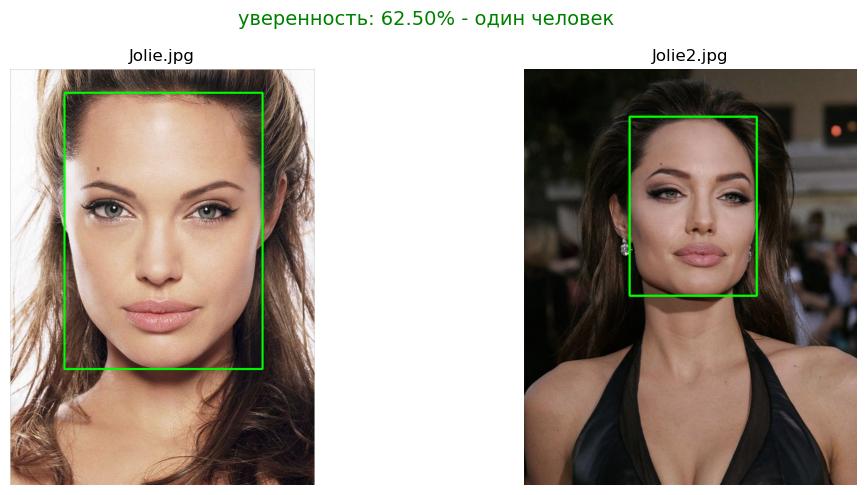

In [37]:
confidence = model.run(
    'C:/Users/User/Desktop/Jolie.jpg',
    'C:/Users/User/Desktop/Jolie2.jpg'
    )

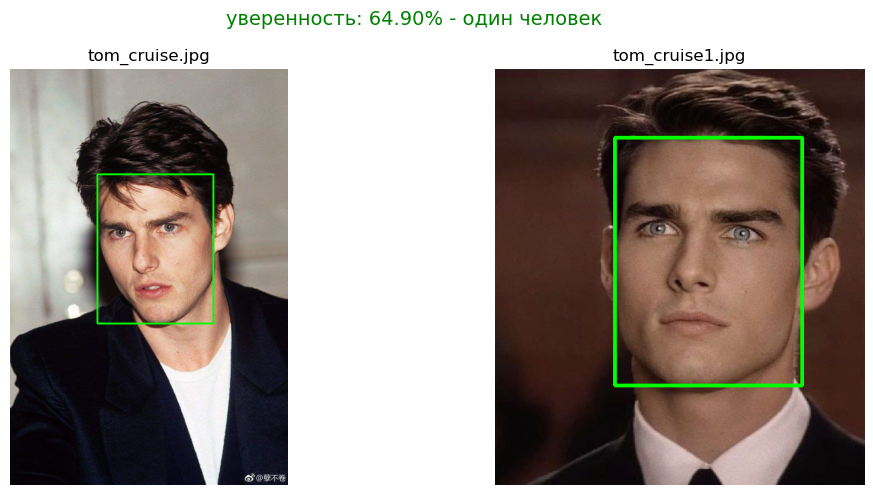

In [38]:
confidence = model.run(
    'C:/Users/User/Desktop/tom_cruise.jpg',
    'C:/Users/User/Desktop/tom_cruise1.jpg'
    )

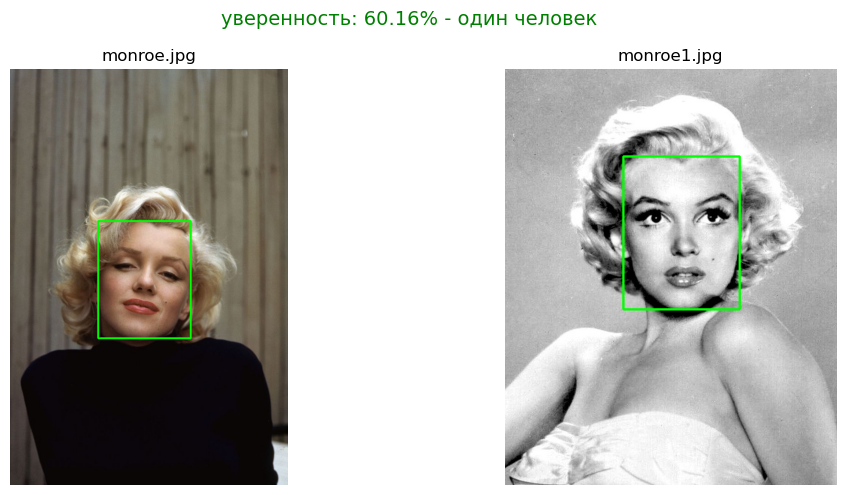

In [39]:
confidence = model.run(
    'C:/Users/User/Desktop/monroe.jpg',
    'C:/Users/User/Desktop/monroe1.jpg'
    )

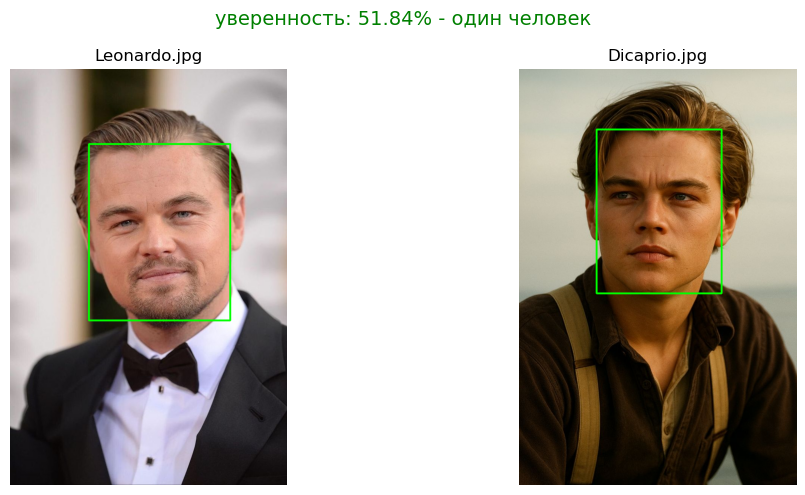

In [40]:
confidence = model.run(
    'C:/Users/User/Desktop/Leonardo.jpg',
    'C:/Users/User/Desktop/Dicaprio.jpg'
    )

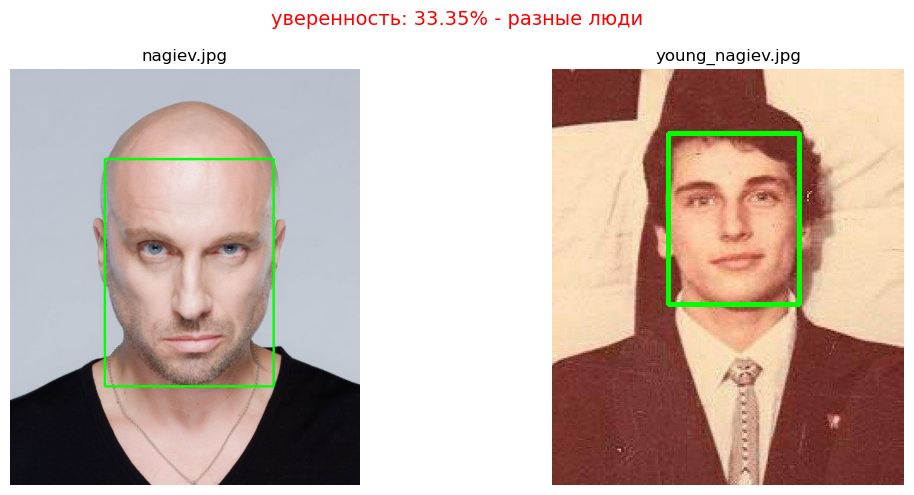

In [41]:
confidence = model.run(
    'C:/Users/User/Desktop/nagiev.jpg',
    'C:/Users/User/Desktop/young_nagiev.jpg'
    )

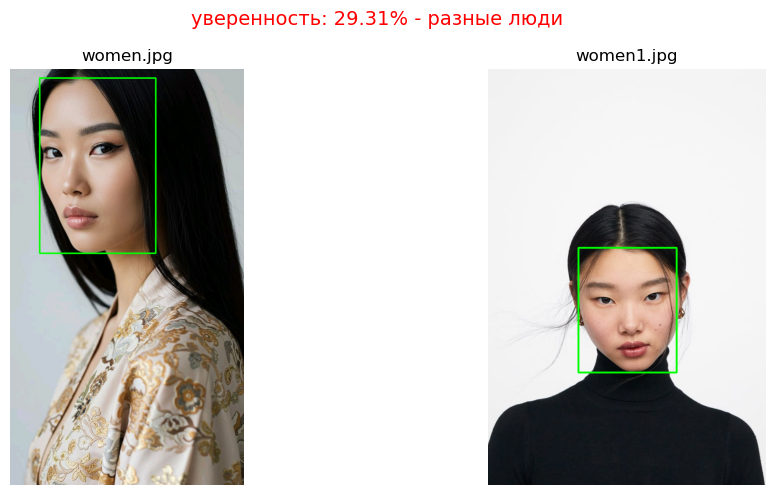

In [42]:
confidence = model.run(
    'C:/Users/User/Desktop/women.jpg',
    'C:/Users/User/Desktop/women1.jpg'
    )